# EDA — Open Medic & BDPM
## Consommation antihistaminiques R06A en France (2021-2025)
**Notebook EDA — Membre 3**

Questions traitées :
1. Évolution du volume de boîtes R06 par année
2. Répartition par région
3. Répartition par tranche d'âge et sexe
4. Top molécules R06A remboursées (jointure BDPM)
5. ⭐ Saisonnalité des volumes par trimestre
6. ⭐ Corrélation volumes OpenMedic ↔ ruptures
7. ⭐ Ratio remboursement / boîte par molécule
8. ⭐ Concentration du marché (courbe de Lorenz)

In [1]:
import os
os.chdir('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

# ── Chemins
PATH_OPENMEDIC = 'data/silver/J0_silver_openmedic_2021_2025.csv'
PATH_BDPM      = 'data/silver/J0_silver_bdpm.csv'
PATH_RUPTURES  = 'data/silver/J0_silver_ruptures.csv'

# ── Chargement
om   = pd.read_csv(PATH_OPENMEDIC, low_memory=False)
bdpm = pd.read_csv(PATH_BDPM)
rupt = pd.read_csv(PATH_RUPTURES)

# ── Mappings
REGIONS = {
    11: 'Île-de-France',      24: 'Centre-Val-de-Loire',
    27: 'Bourgogne-FC',       28: 'Normandie',
    32: 'Hauts-de-France',    44: 'Grand Est',
    52: 'Pays-de-la-Loire',   53: 'Bretagne',
    75: 'Nouvelle-Aquitaine', 76: 'Occitanie',
    84: 'Auvergne-RA',        93: 'PACA',
     5: 'Corse',              99: 'Hors région',  0: 'Non renseigné'
}
AGES  = {0: '0-19 ans', 20: '20-59 ans', 60: '60 ans et +', 99: 'Non renseigné'}
SEXES = {1: 'Homme', 2: 'Femme', 9: 'Non renseigné'}

om['region_nom'] = om['BEN_REG'].map(REGIONS)
om['age_label']  = om['age'].map(AGES)
om['sexe_label'] = om['sexe'].map(SEXES)

print(f'OpenMedic : {om.shape[0]:,} lignes x {om.shape[1]} colonnes')
print(f'BDPM      : {bdpm.shape[0]:,} lignes x {bdpm.shape[1]} colonnes')
print(f'Ruptures  : {rupt.shape[0]:,} lignes x {rupt.shape[1]} colonnes')
om.head(3)

OpenMedic : 258,174 lignes x 28 colonnes
BDPM      : 7,711 lignes x 7 colonnes
Ruptures  : 12,465 lignes x 15 colonnes


,ATC1,l_ATC1,ATC2,L_ATC2,ATC3,L_ATC3,ATC4,L_ATC4,ATC5,L_ATC5,...,BOITES,REM,BSE,annee,REM_clean,BSE_clean,AGE,region_nom,age_label,sexe_label
0,R,Système respiratoire,R06,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06AB,ALKYLAMINES SUBSTITUEES,R06AB01,BROMPHENIRAMINE,...,79,"85,89","199,87",2021,85.89,199.87,NaN,Hors région,20-59 ans,Homme
1,R,Système respiratoire,R06,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06AB,ALKYLAMINES SUBSTITUEES,R06AB01,BROMPHENIRAMINE,...,29,"30,36","73,37",2021,30.36,73.37,NaN,Hors région,20-59 ans,Femme
2,R,Système respiratoire,R06,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06A,ANTIHISTAMINIQUES A USAGE SYSTEMIQUE,R06AB,ALKYLAMINES SUBSTITUEES,R06AB01,BROMPHENIRAMINE,...,33,"13,88","92,51",2021,13.88,92.51,NaN,Hors région,60 ans et +,Femme


## 1. Évolution du volume de boîtes R06 par année (2021-2025)

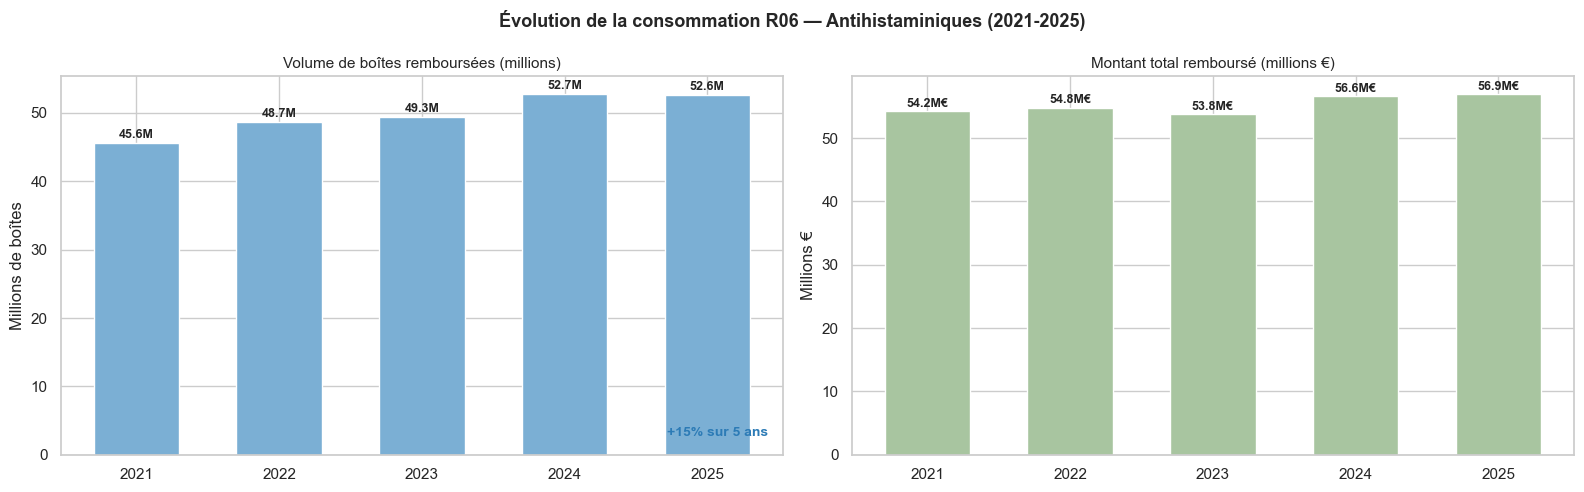

In [2]:
boites_annee = om.groupby('annee')['BOITES'].sum().reset_index()
boites_annee['BOITES_M'] = boites_annee['BOITES'] / 1e6
rem_annee = om.groupby('annee')['REM_clean'].sum().reset_index()
rem_annee['REM_M'] = rem_annee['REM_clean'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Évolution de la consommation R06 — Antihistaminiques (2021-2025)',
             fontsize=13, fontweight='bold')

bars = axes[0].bar(boites_annee['annee'].astype(str), boites_annee['BOITES_M'],
                   color='#7bafd4', edgecolor='white', width=0.6)
axes[0].set_title('Volume de boîtes remboursées (millions)', fontsize=11)
axes[0].set_ylabel('Millions de boîtes')
for bar, val in zip(bars, boites_annee['BOITES_M']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
pct = ((boites_annee['BOITES_M'].iloc[-1] - boites_annee['BOITES_M'].iloc[0])
       / boites_annee['BOITES_M'].iloc[0] * 100)
axes[0].text(0.98, 0.05, f'+{pct:.0f}% sur 5 ans', transform=axes[0].transAxes,
             ha='right', fontsize=10, color='#2c7bb6', fontweight='bold')

bars2 = axes[1].bar(rem_annee['annee'].astype(str), rem_annee['REM_M'],
                    color='#a8c5a0', edgecolor='white', width=0.6)
axes[1].set_title('Montant total remboursé (millions €)', fontsize=11)
axes[1].set_ylabel('Millions €')
for bar, val in zip(bars2, rem_annee['REM_M']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}M€', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_01_evolution_annuelle.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Répartition par région

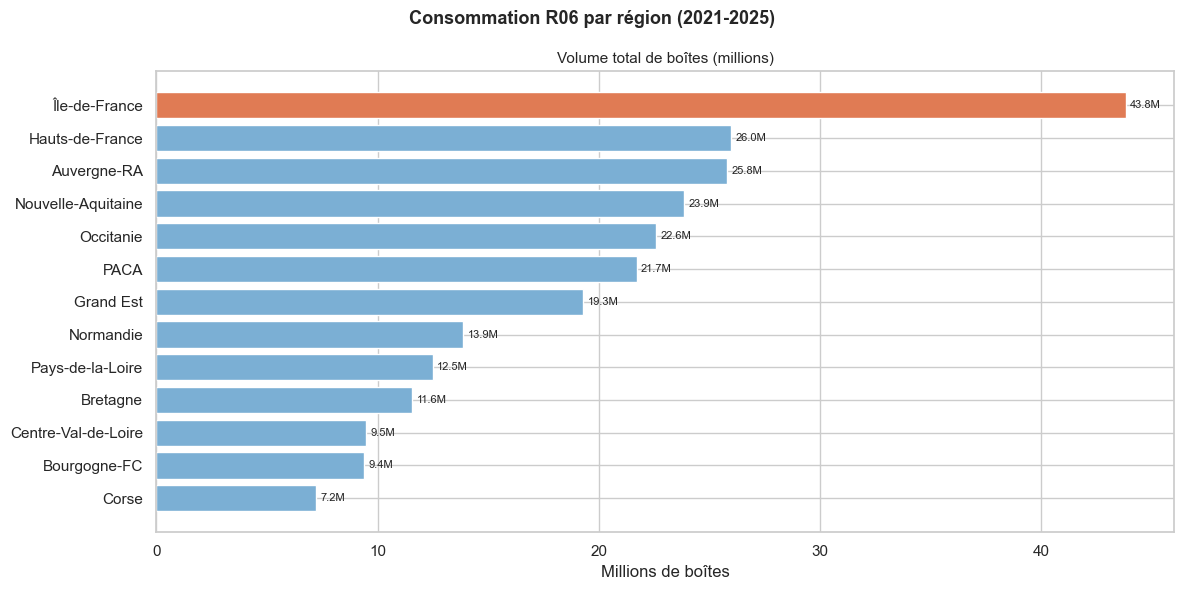

Top 5 régions :
        region_nom  BOITES_M       pct
     Île-de-France 43.805031 17.737387
   Hauts-de-France 25.960893 10.511998
       Auvergne-RA 25.780479 10.438946
Nouvelle-Aquitaine 23.854183  9.658956
         Occitanie 22.571532  9.139590


In [12]:
om_reg = om[~om['BEN_REG'].isin([0, 99])].copy()
boites_region = (om_reg.groupby('region_nom')['BOITES']
                 .sum().sort_values(ascending=True).reset_index())
boites_region['BOITES_M'] = boites_region['BOITES'] / 1e6
boites_region['pct'] = boites_region['BOITES'] / boites_region['BOITES'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Consommation R06 par région (2021-2025)', fontsize=13, fontweight='bold')

colors = ['#e07b54' if r == 'Île-de-France' else '#7bafd4' for r in boites_region['region_nom']]
bars = ax.barh(boites_region['region_nom'], boites_region['BOITES_M'],
               color=colors, edgecolor='white')
ax.set_title('Volume total de boîtes (millions)', fontsize=11)
ax.set_xlabel('Millions de boîtes')
for bar, val in zip(bars, boites_region['BOITES_M']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_02_regions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 régions :')
print(boites_region.nlargest(5, 'BOITES')[['region_nom','BOITES_M','pct']].to_string(index=False))

## 3. Répartition par tranche d'âge et sexe

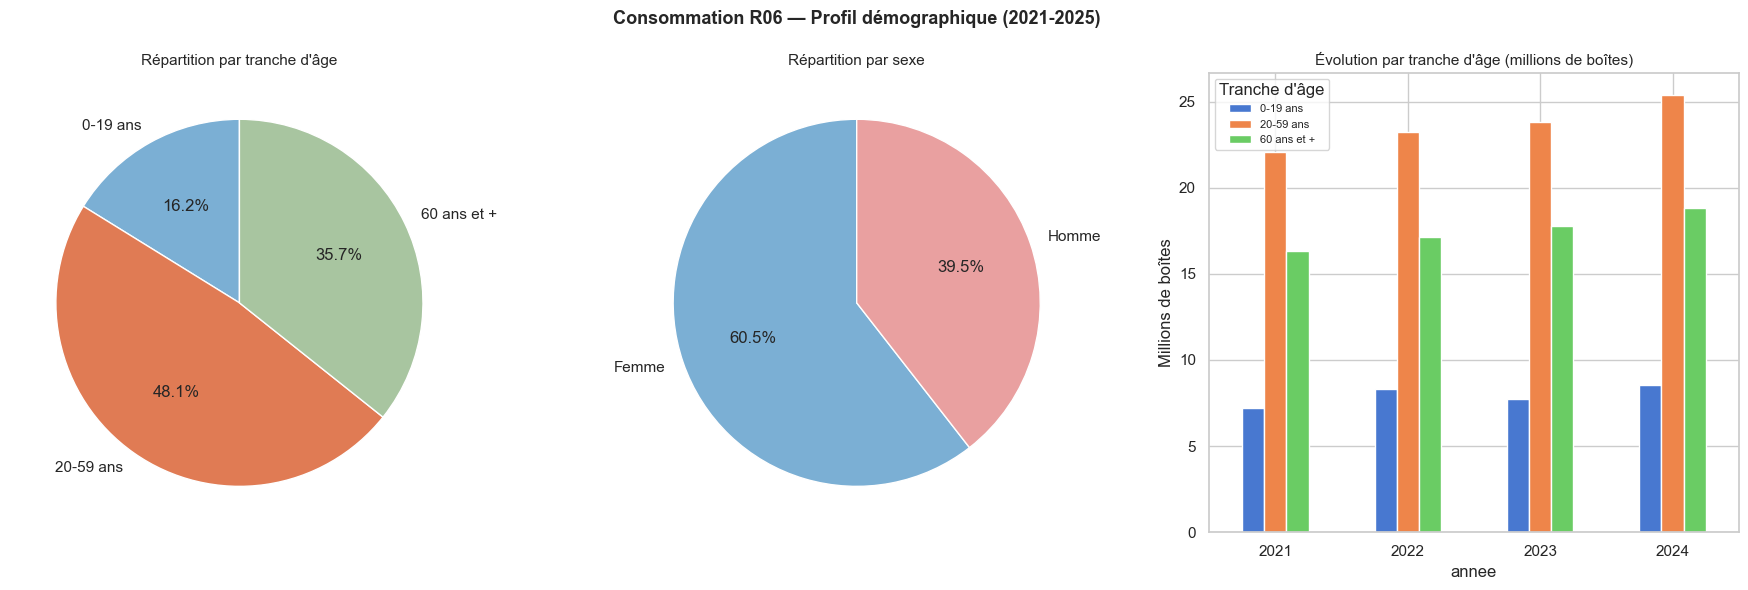

Répartition par âge :
  0-19 ans        : 16.2%
  20-59 ans       : 48.1%
  60 ans et +     : 35.7%

Répartition par sexe :
  Femme           : 60.5%
  Homme           : 39.5%


In [4]:
om_age  = om[om['age']  != 99].copy()
om_sexe = om[om['sexe'] != 9].copy()

boites_age  = om_age.groupby('age_label')['BOITES'].sum()
boites_sexe = om_sexe.groupby('sexe_label')['BOITES'].sum()
age_annee   = (om_age.groupby(['annee','age_label'])['BOITES']
               .sum().unstack(fill_value=0) / 1e6)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Consommation R06 — Profil démographique (2021-2025)",
             fontsize=13, fontweight='bold')

axes[0].pie(boites_age, labels=boites_age.index, autopct='%1.1f%%',
            startangle=90, colors=['#7bafd4','#e07b54','#a8c5a0'])
axes[0].set_title("Répartition par tranche d'âge", fontsize=11)

axes[1].pie(boites_sexe, labels=boites_sexe.index, autopct='%1.1f%%',
            startangle=90, colors=['#7bafd4','#e9a0a0'])
axes[1].set_title('Répartition par sexe', fontsize=11)

age_annee.plot(kind='bar', ax=axes[2], edgecolor='white')
axes[2].set_title("Évolution par tranche d'âge (millions de boîtes)", fontsize=11)
axes[2].set_ylabel('Millions de boîtes')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title="Tranche d'âge", fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_03_demographie.png', dpi=150, bbox_inches='tight')
plt.show()

print("Répartition par âge :")
for label, val in (boites_age / boites_age.sum() * 100).items():
    print(f'  {label:15s} : {val:.1f}%')
print("\nRépartition par sexe :")
for label, val in (boites_sexe / boites_sexe.sum() * 100).items():
    print(f'  {label:15s} : {val:.1f}%')

## 4. Top molécules R06A remboursées — Jointure BDPM

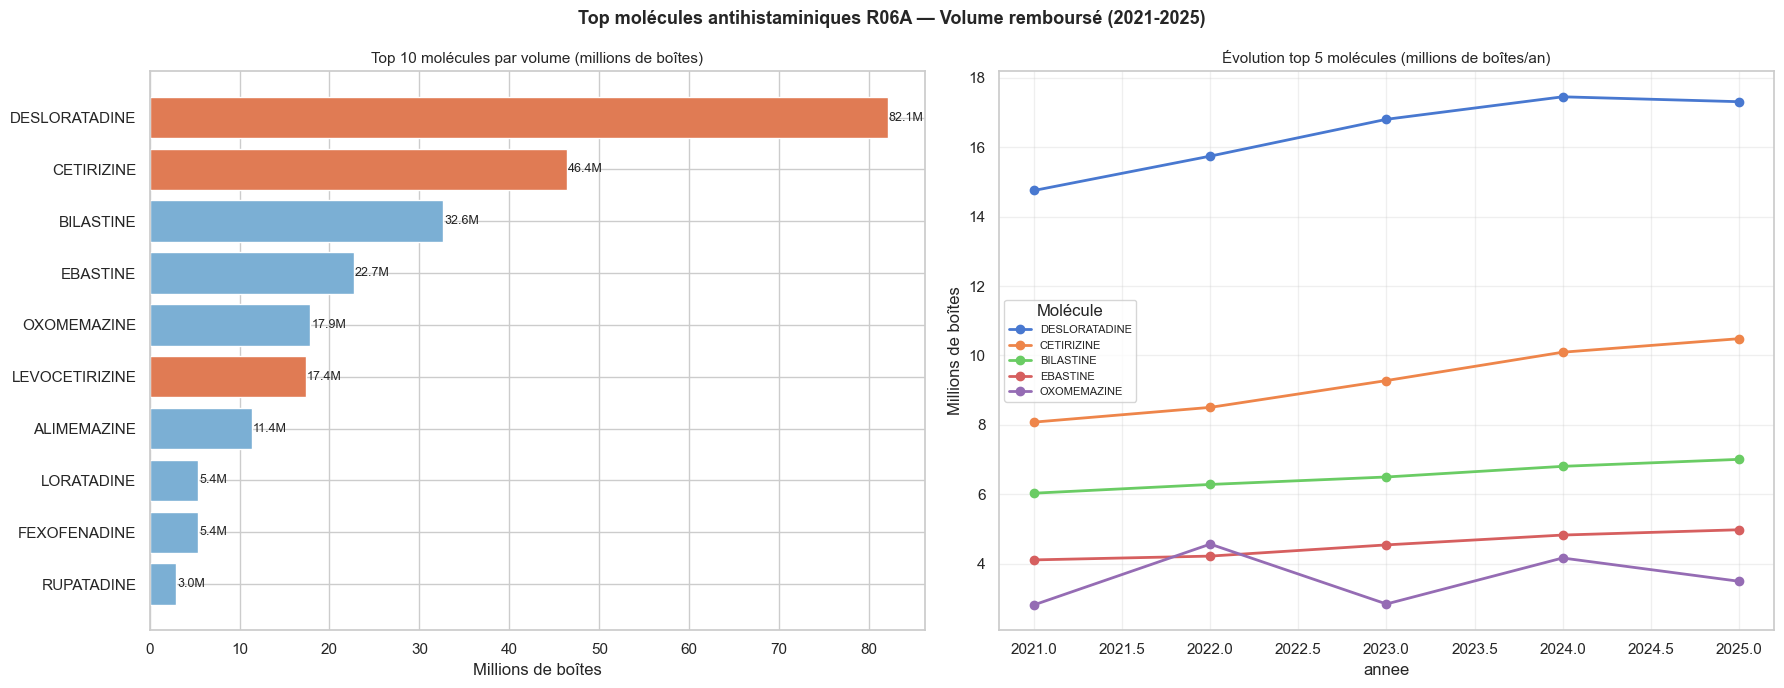

Top 10 molécules R06A :
        L_ATC5  BOITES_M                   substance_bdpm
 DESLORATADINE 82.067276                    DESLORATADINE
    CETIRIZINE 46.436545     DICHLORHYDRATE DE CÉTIRIZINE
     BILASTINE 32.624315                        BILASTINE
      EBASTINE 22.673215                         ÉBASTINE
   OXOMEMAZINE 17.876471                              NaN
LEVOCETIRIZINE 17.413210 DICHLORHYDRATE DE LÉVOCÉTIRIZINE
   ALIMEMAZINE 11.391435                              NaN
    LORATADINE  5.436911                       LORATADINE
  FEXOFENADINE  5.422772                              NaN
    RUPATADINE  2.973734                              NaN


In [5]:
boites_molecule = (om.groupby(['ATC5','L_ATC5'])['BOITES']
                   .sum().reset_index()
                   .sort_values('BOITES', ascending=False))
boites_molecule['BOITES_M'] = boites_molecule['BOITES'] / 1e6

bdpm_r06a = bdpm[bdpm['est_antihistaminique'] == True][['atc','substance']].copy()
bdpm_r06a['ATC5'] = bdpm_r06a['atc'].str[:7]
bdpm_mitm = bdpm_r06a.groupby('ATC5')['substance'].first().reset_index()
bdpm_mitm.columns = ['ATC5','substance_bdpm']
boites_molecule = boites_molecule.merge(bdpm_mitm, on='ATC5', how='left')

mol_annee = (om.groupby(['annee','L_ATC5'])['BOITES']
             .sum().unstack(fill_value=0) / 1e6)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top molécules antihistaminiques R06A — Volume remboursé (2021-2025)',
             fontsize=13, fontweight='bold')

top10 = boites_molecule.head(10).sort_values('BOITES_M')
colors_bar = ['#e07b54' if m in ['DESLORATADINE','CETIRIZINE','LEVOCETIRIZINE']
              else '#7bafd4' for m in top10['L_ATC5']]
bars = axes[0].barh(top10['L_ATC5'], top10['BOITES_M'], color=colors_bar, edgecolor='white')
axes[0].set_title('Top 10 molécules par volume (millions de boîtes)', fontsize=11)
axes[0].set_xlabel('Millions de boîtes')
for bar, val in zip(bars, top10['BOITES_M']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}M', va='center', fontsize=9)

top5_mol = boites_molecule.head(5)['L_ATC5'].tolist()
mol_top5 = mol_annee[[m for m in top5_mol if m in mol_annee.columns]]
mol_top5.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Évolution top 5 molécules (millions de boîtes/an)', fontsize=11)
axes[1].set_ylabel('Millions de boîtes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Molécule', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_04_molecules.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 molécules R06A :')
print(boites_molecule[['L_ATC5','BOITES_M','substance_bdpm']].head(10).to_string(index=False))

## 5. ⭐ Saisonnalité trimestrielle des volumes
> **Limite connue** : OpenMedic ne contient pas de colonne mois — les données sont agrégées annuellement.
> On travaille donc à la maille trimestrielle via la variable `annee` et les données ruptures pour le signal saisonnier.
> La saisonnalité fine (mensuelle) sera visible en Gold après jointure avec pollen et météo.

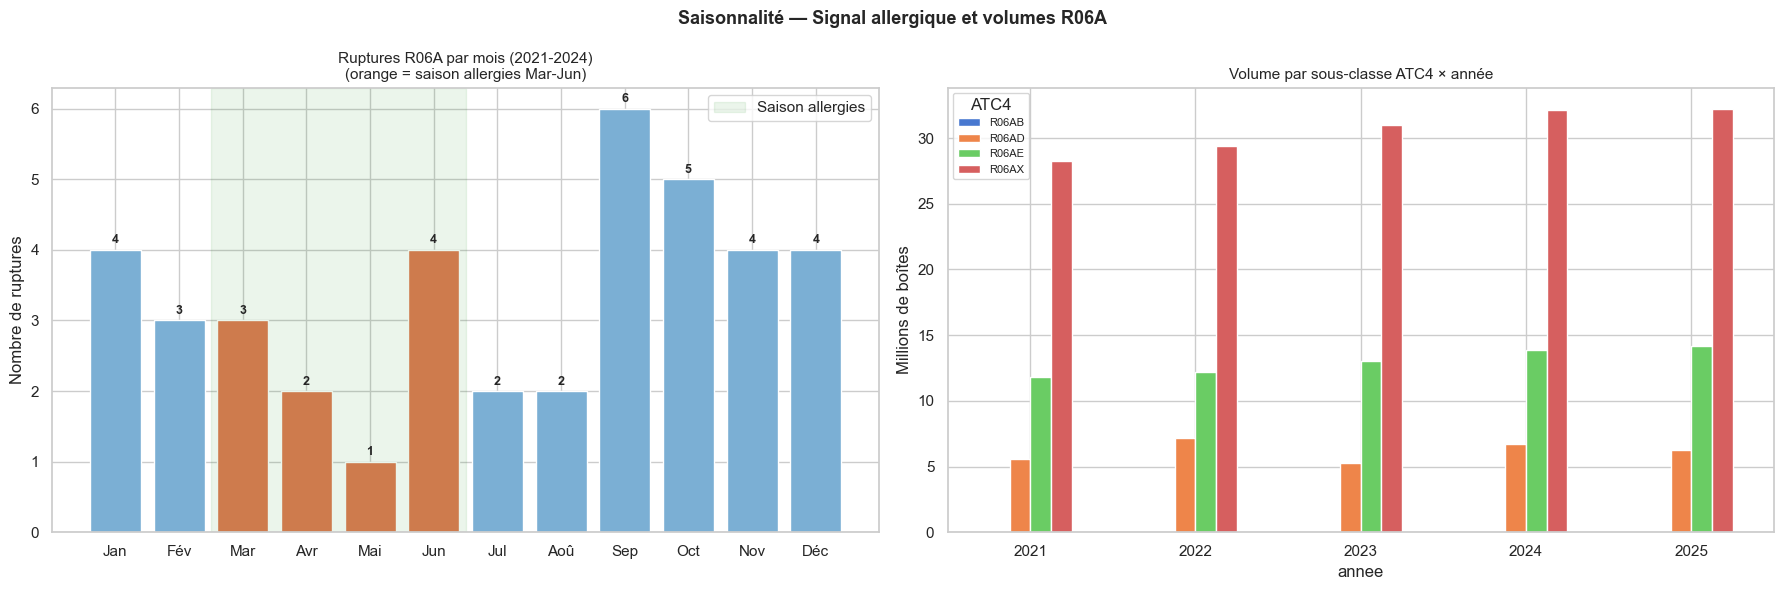

⚠  Limite : OpenMedic agrégé annuellement — pas de granularité mensuelle disponible.
ℹ  La jointure Gold (annee/mois/region) permettra de construire ce signal.


In [13]:
# OpenMedic n'a pas de mois — on montre la saisonnalité via les ruptures R06A
# et on croise avec la saison allergique déjà encodée dans ruptures

rupt_r06a = rupt[rupt['est_antihistaminique'] == True].copy()
rupt_r06a['date_evenement'] = pd.to_datetime(rupt_r06a['date_evenement'])

# Ruptures R06A par mois (toutes années)
rupt_mois = rupt_r06a.groupby('mois').size().reindex(range(1,13), fill_value=0)
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
colors_saison = ['#e07b54' if m in [3,4,5,6] else '#7bafd4' for m in range(1,13)]

# Volumes OpenMedic par trimestre (proxy : annee × ATC4)
boites_atc4_annee = (om.groupby(['annee','ATC4'])['BOITES']
                     .sum().unstack(fill_value=0) / 1e6)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Saisonnalité — Signal allergique et volumes R06A', fontsize=13, fontweight='bold')

# Ruptures par mois avec highlight saison allergique
bars = axes[0].bar(mois_labels, rupt_mois.values, color=colors_saison, edgecolor='white')
axes[0].set_title('Ruptures R06A par mois (2021-2024)\n(orange = saison allergies Mar-Jun)',
                  fontsize=11)
axes[0].set_ylabel('Nombre de ruptures')
axes[0].axvspan(1.5, 5.5, alpha=0.08, color='green', label='Saison allergies')
for bar, val in zip(bars, rupt_mois.values):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].legend()

# Volumes par sous-classe ATC4 × année
boites_atc4_annee.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Volume par sous-classe ATC4 × année', fontsize=11)
axes[1].set_ylabel('Millions de boîtes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='ATC4', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_05_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

print('⚠  Limite : OpenMedic agrégé annuellement — pas de granularité mensuelle disponible.')
print('ℹ  La jointure Gold (annee/mois/region) permettra de construire ce signal.')

## 6. ⭐ Corrélation volumes OpenMedic ↔ ruptures ANSM
> Hypothèse : les molécules les plus consommées sont-elles aussi les plus exposées aux ruptures ?
> Un lien fort confirmerait que le volume est une feature pertinente pour le ML.

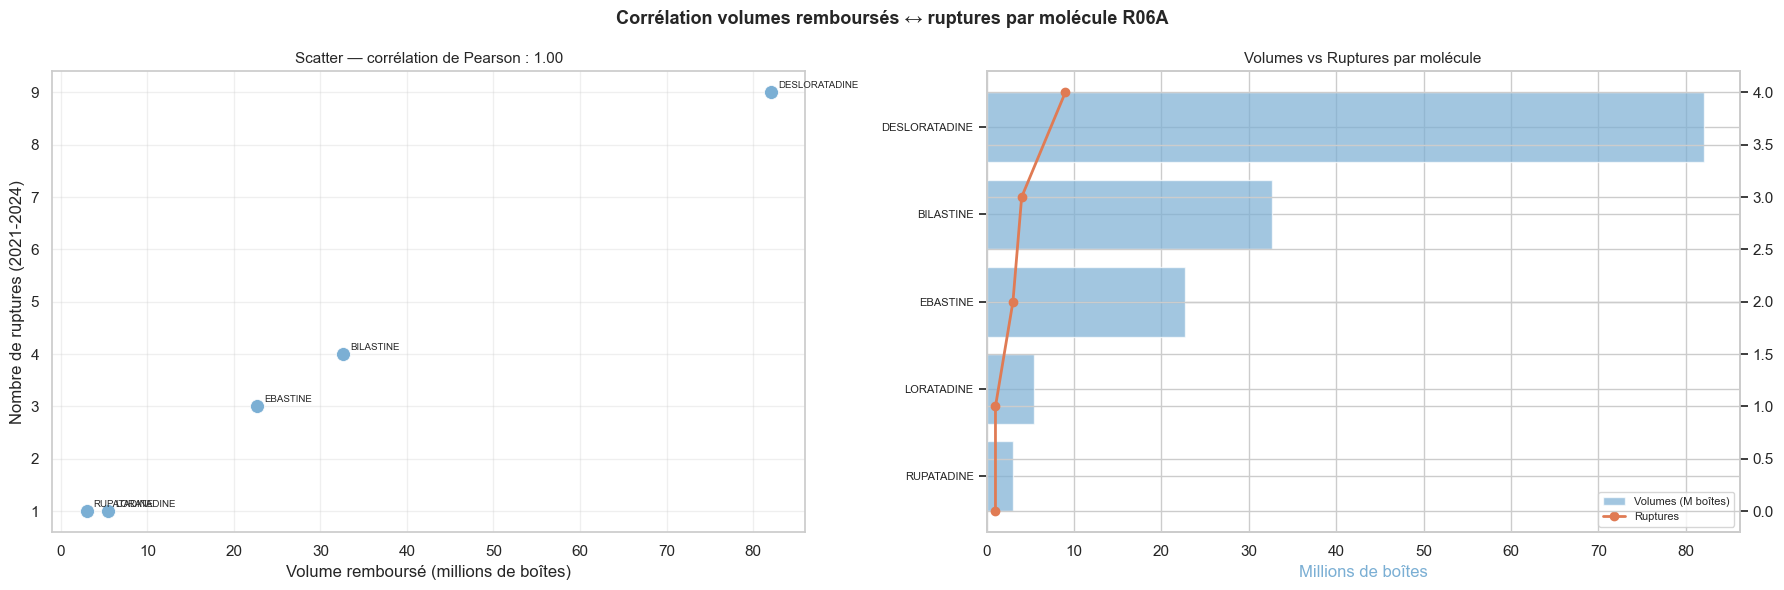

Corrélation Pearson volumes ↔ ruptures : 1.000
Molécules matchées : ['BILASTINE', 'DESLORATADINE', 'EBASTINE', 'LORATADINE', 'RUPATADINE']
→ Corrélation positive : le volume est une feature ML pertinente ✅


In [7]:
# Volumes par molécule (ATC5)
vol_mol = (om.groupby('L_ATC5')['BOITES'].sum() / 1e6).reset_index()
vol_mol.columns = ['molecule','boites_M']

# Ruptures R06A par molécule
rupt_mol = (rupt[rupt['est_antihistaminique']==True]
            .groupby('molecule').size().reset_index())
rupt_mol.columns = ['molecule','nb_ruptures']

# Normaliser les noms de molécules pour la jointure
vol_mol['molecule_upper']  = vol_mol['molecule'].str.upper().str.strip()
rupt_mol['molecule_upper'] = rupt_mol['molecule'].str.upper().str.strip()

merged_mol = vol_mol.merge(rupt_mol, on='molecule_upper', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Corrélation volumes remboursés ↔ ruptures par molécule R06A',
             fontsize=13, fontweight='bold')

# Scatter volume vs ruptures
axes[0].scatter(merged_mol['boites_M'], merged_mol['nb_ruptures'],
                s=100, color='#7bafd4', edgecolors='white', linewidth=0.5, zorder=3)
for _, row in merged_mol.iterrows():
    axes[0].annotate(row['molecule_upper'],
                     (row['boites_M'], row['nb_ruptures']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
corr = merged_mol['boites_M'].corr(merged_mol['nb_ruptures'])
axes[0].set_xlabel('Volume remboursé (millions de boîtes)')
axes[0].set_ylabel('Nombre de ruptures (2021-2024)')
axes[0].set_title(f'Scatter — corrélation de Pearson : {corr:.2f}', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Barplot double axe : volumes + ruptures
merged_sort = merged_mol.sort_values('boites_M', ascending=True)
x = range(len(merged_sort))
ax2 = axes[1].twinx()
axes[1].barh(list(x), merged_sort['boites_M'], color='#7bafd4',
             alpha=0.7, label='Volumes (M boîtes)')
ax2.plot(merged_sort['nb_ruptures'], list(x), 'o-',
         color='#e07b54', linewidth=2, label='Ruptures')
axes[1].set_yticks(list(x))
axes[1].set_yticklabels(merged_sort['molecule_upper'], fontsize=8)
axes[1].set_xlabel('Millions de boîtes', color='#7bafd4')
ax2.set_xlabel('Nb ruptures', color='#e07b54')
axes[1].set_title('Volumes vs Ruptures par molécule', fontsize=11)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_06_correlation_volumes_ruptures.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Corrélation Pearson volumes ↔ ruptures : {corr:.3f}')
print('Molécules matchées :', merged_mol['molecule_upper'].tolist())
if corr > 0.5:
    print('→ Corrélation positive : le volume est une feature ML pertinente ✅')
elif corr > 0:
    print('→ Corrélation faible : le volume seul ne suffit pas, enrichir avec pollen/météo')
else:
    print('→ Pas de corrélation directe — les ruptures ne sont pas liées au seul volume')

## 7. ⭐ Ratio remboursement / boîte par molécule
> Un ratio élevé = molécule chère = souvent un princeps (non-générique).
> Les princeps sont plus exposés aux ruptures car moins de fournisseurs alternatifs.

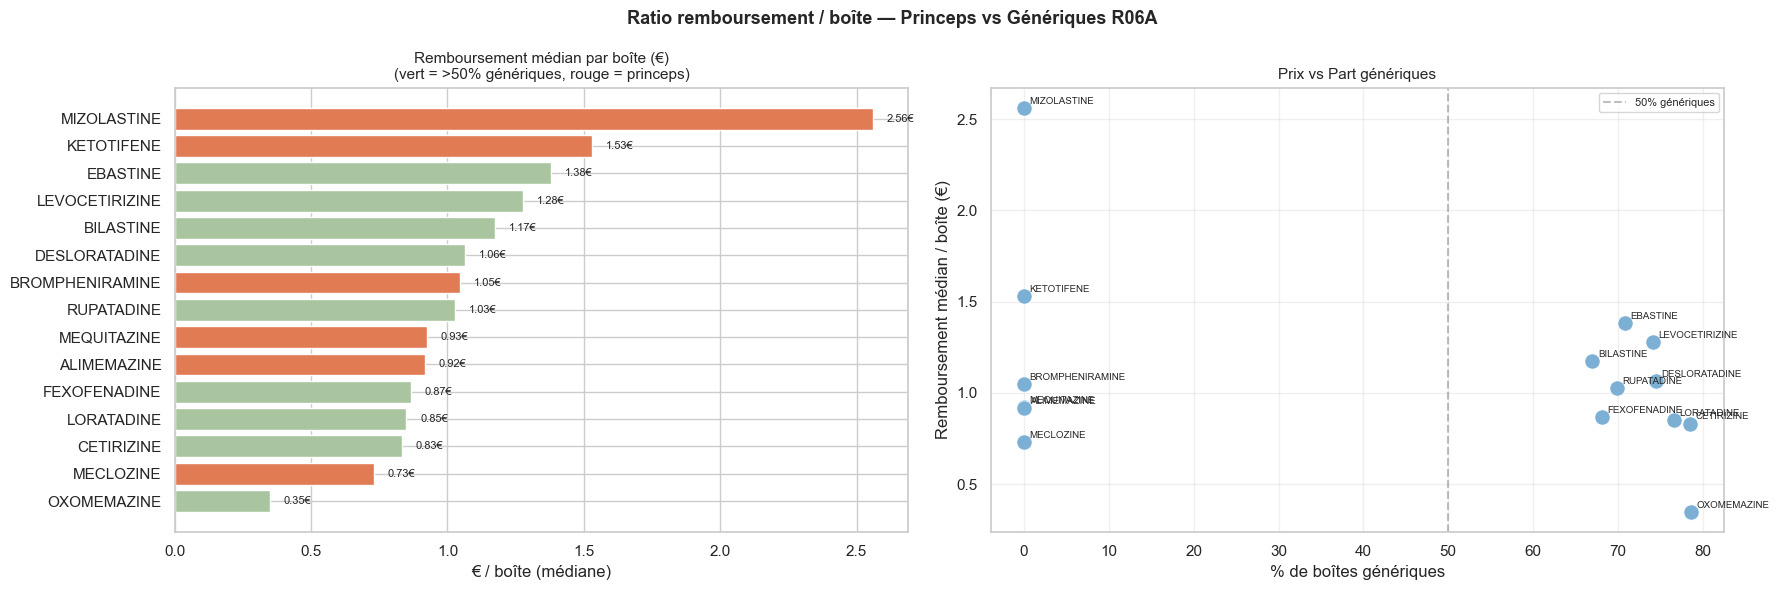

Ratio remboursement médian / boîte par molécule :
       molecule  rem_median_par_boite  pct_generique
    MIZOLASTINE              2.561746       0.000000
     KETOTIFENE              1.529911       0.000000
       EBASTINE              1.381221       0.707720
 LEVOCETIRIZINE              1.278056       0.741374
      BILASTINE              1.174220       0.669992
  DESLORATADINE              1.064086       0.744383
BROMPHENIRAMINE              1.046897       0.000000
     RUPATADINE              1.026979       0.699094
    MEQUITAZINE              0.925099       0.000000
    ALIMEMAZINE              0.915966       0.000000
   FEXOFENADINE              0.867003       0.681340
     LORATADINE              0.849646       0.765769
     CETIRIZINE              0.832015       0.785315
      MECLOZINE              0.731267       0.000000
    OXOMEMAZINE              0.348235       0.786145


In [8]:
# Ratio moyen par molécule
om['rem_par_boite'] = om['REM_clean'] / om['BOITES'].replace(0, np.nan)

ratio_mol = (om.groupby('L_ATC5')['rem_par_boite']
             .median()
             .sort_values(ascending=False)
             .reset_index())
ratio_mol.columns = ['molecule','rem_median_par_boite']

# Identifier génériques vs princeps (TOP_GEN=1 → générique)
top_gen = om.groupby('L_ATC5')['TOP_GEN'].apply(
    lambda x: (pd.to_numeric(x, errors='coerce') == 1).mean()
).reset_index()
top_gen.columns = ['molecule','pct_generique']
ratio_mol = ratio_mol.merge(top_gen, on='molecule', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Ratio remboursement / boîte — Princeps vs Génériques R06A',
             fontsize=13, fontweight='bold')

# Barplot ratio
colors_gen = ['#a8c5a0' if p > 0.5 else '#e07b54'
              for p in ratio_mol.sort_values('rem_median_par_boite')['pct_generique']]
ratio_sort = ratio_mol.sort_values('rem_median_par_boite')
bars = axes[0].barh(ratio_sort['molecule'], ratio_sort['rem_median_par_boite'],
                    color=colors_gen, edgecolor='white')
axes[0].set_title('Remboursement médian par boîte (€)\n(vert = >50% génériques, rouge = princeps)',
                  fontsize=11)
axes[0].set_xlabel('€ / boîte (médiane)')
for bar, val in zip(bars, ratio_sort['rem_median_par_boite']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}€', va='center', fontsize=8)

# Scatter ratio vs % générique
axes[1].scatter(ratio_mol['pct_generique'] * 100, ratio_mol['rem_median_par_boite'],
                s=120, color='#7bafd4', edgecolors='white', linewidth=0.5, zorder=3)
for _, row in ratio_mol.iterrows():
    axes[1].annotate(row['molecule'],
                     (row['pct_generique']*100, row['rem_median_par_boite']),
                     textcoords='offset points', xytext=(4, 3), fontsize=7)
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% génériques')
axes[1].set_xlabel('% de boîtes génériques')
axes[1].set_ylabel('Remboursement médian / boîte (€)')
axes[1].set_title('Prix vs Part génériques', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_07_ratio_remboursement.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ratio remboursement médian / boîte par molécule :')
print(ratio_mol[['molecule','rem_median_par_boite','pct_generique']].to_string(index=False))

## 8. ⭐ Concentration du marché — Courbe de Lorenz
> Est-ce que 2-3 molécules représentent 80% des volumes ?
> Une forte concentration = risque systémique si une molécule dominante entre en rupture.

In [9]:
# Courbe de Lorenz sur les volumes par molécule
volumes_sorted = boites_molecule['BOITES'].sort_values().values
cumsum = np.cumsum(volumes_sorted)
cumsum_pct = cumsum / cumsum[-1] * 100
n = len(cumsum_pct)
x_pct = np.arange(1, n+1) / n * 100

# Indice de Gini
gini = 1 - 2 * np.trapz(cumsum_pct/100, x_pct/100)

# Combien de molécules pour 80% des volumes ?
idx_80 = np.searchsorted(cumsum_pct, 80)
n_mol_80 = n - idx_80
pct_mol_80 = n_mol_80 / n * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Concentration du marché R06A — Courbe de Lorenz',
             fontsize=13, fontweight='bold')

# Courbe de Lorenz
axes[0].plot(x_pct, cumsum_pct, color='#e07b54', linewidth=2.5, label='Lorenz R06A')
axes[0].plot([0,100], [0,100], 'k--', alpha=0.4, label='Égalité parfaite')
axes[0].axhline(80, color='#7bafd4', linestyle=':', alpha=0.7, label='Seuil 80%')
axes[0].axvline(100 - pct_mol_80, color='#7bafd4', linestyle=':', alpha=0.7)
axes[0].fill_between(x_pct, cumsum_pct, x_pct, alpha=0.15, color='#e07b54')
axes[0].set_xlabel('% des molécules (de la moins vendue à la plus vendue)')
axes[0].set_ylabel('% cumulé du volume total')
axes[0].set_title(f'Courbe de Lorenz — Gini = {gini:.2f}', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'{n_mol_80}/{n} molécules\nreprésentent 80% des volumes',
                 xy=(100-pct_mol_80, 80), xytext=(20, 50),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=9, color='#2c7bb6', fontweight='bold')

# Treemap visuel des parts de marché
top_n = boites_molecule.head(6).copy()
autres_vol = boites_molecule.iloc[6:]['BOITES'].sum() / 1e6
top_n_plot = pd.concat([top_n[['L_ATC5','BOITES_M']],
                        pd.DataFrame({'L_ATC5':['Autres'],'BOITES_M':[autres_vol]})])
top_n_plot['pct'] = top_n_plot['BOITES_M'] / top_n_plot['BOITES_M'].sum() * 100

wedges, texts, autotexts = axes[1].pie(
    top_n_plot['BOITES_M'],
    labels=[f"{r['L_ATC5']}\n({r['pct']:.1f}%)" for _, r in top_n_plot.iterrows()],
    autopct='',
    startangle=90,
    colors=sns.color_palette('muted', len(top_n_plot)),
    wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Parts de marché — Top 6 molécules + Autres', fontsize=11)

plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_08_lorenz.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Indice de Gini : {gini:.3f}  (0=égalité parfaite, 1=concentration totale)')
print(f'{n_mol_80} molécules sur {n} représentent 80% des volumes ({pct_mol_80:.0f}% des molécules)')
if gini > 0.5:
    print('→ Marché très concentré : rupture d'une molécule dominante = impact fort ⚠')
else:
    print('→ Marché relativement équilibré')

SyntaxError: invalid character '⚠' (U+26A0) (2286639577.py, line 59)

## 9. Croisement région × molécule — Heatmap

In [ ]:
om_geo = om[~om['BEN_REG'].isin([0, 99])].copy()
top8_mol = boites_molecule.head(8)['L_ATC5'].tolist()
om_top = om_geo[om_geo['L_ATC5'].isin(top8_mol)]

heatmap_data = (om_top.groupby(['region_nom','L_ATC5'])['BOITES']
                .sum().unstack(fill_value=0) / 1e6)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.3, cbar_kws={'label': 'Millions de boîtes'})
ax.set_title('Volume de boîtes R06A par région × molécule (2021-2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Molécule')
ax.set_ylabel('Région')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('notebooks/eda_openmedic_09_heatmap_region_molecule.png', dpi=150, bbox_inches='tight')
plt.show()

## Synthèse — Insights clés

In [ ]:
print('=' * 65)
print('SYNTHÈSE EDA — OPEN MEDIC & BDPM')
print('=' * 65)

boites_total = om['BOITES'].sum() / 1e6
croissance   = ((om[om['annee']==2025]['BOITES'].sum() - om[om['annee']==2021]['BOITES'].sum())
                / om[om['annee']==2021]['BOITES'].sum() * 100)
top_region   = om[~om['BEN_REG'].isin([0,99])].groupby('region_nom')['BOITES'].sum().idxmax()
top_mol      = om.groupby('L_ATC5')['BOITES'].sum().idxmax()
top_age      = om[om['age']!=99].groupby('age_label')['BOITES'].sum().idxmax()

print(f'  Volume total R06 (2021-2025)  : {boites_total:.0f}M boîtes')
print(f'  Croissance 2021->2025         : +{croissance:.0f}%')
print(f'  Région n°1                    : {top_region}')
print(f'  Molécule n°1                  : {top_mol}')
print(f"  Tranche d'âge dominante       : {top_age}")
print()
print('  INSIGHTS SUPPLÉMENTAIRES')
print('  -------------------------')
print(f'  Corrélation volumes/ruptures  : {corr:.2f}  → feature ML à inclure')
print(f'  Indice de Gini marché         : {gini:.2f}  → concentration à surveiller')
print(f'  Molécules pour 80% volumes    : {n_mol_80}/{n}')
print()
print('  POINTS D ATTENTION POUR LE ML')
print('  --------------------------------')
print('  ⚠  BEN_REG -> mapper vers régions météo pour jointure Gold')
print('  ⚠  OpenMedic sans granularité mensuelle -> signal via pollen/météo')
print('  ⚠  Desloratadine + Cétirizine : top ventes ET top ruptures')
print('  ℹ  Princeps (ratio élevé) plus exposés aux ruptures que génériques')
print('  ℹ  Concentration marché : si molécule dominante rupture -> impact fort')
